1. Imports & Config

In [2]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils.prune as prune

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, Subset

import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

os.makedirs("../checkpoints", exist_ok=True)
os.makedirs("../results", exist_ok=True)

Using device: cpu


2. Dataset Loading

In [4]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

train_dataset = torchvision.datasets.CIFAR10(
    root="../data",
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = torchvision.datasets.CIFAR10(
    root="../data",
    train=False,
    download=True,
    transform=transform_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset)) 

100%|██████████| 170M/170M [1:54:27<00:00, 24.8kB/s]  


Train size: 50000
Test size: 10000


In [5]:
small_val_indices = list(range(1000))

small_val_dataset = Subset(test_dataset, small_val_indices)

small_val_loader = DataLoader(
    small_val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

print("Small validation size:", len(small_val_dataset))

Small validation size: 1000


3. CNN Model

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # features.0
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # features.3
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1), # features.6
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),                 # classifier.1
            nn.ReLU(),
            nn.Linear(256, 10)                           # classifier.3
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

4. Train & Evaluate Baseline

In [7]:
def train_model(model, train_loader, criterion, optimizer, device, epochs=10):
    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        avg_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total

        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Loss: {avg_loss:.4f} | "
            f"Train Accuracy: {train_accuracy:.2f}%"
        )

In [8]:
def evaluate_model(model, data_loader, device, print_result=True):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    if print_result:
        print(f"Accuracy: {accuracy:.2f}%")

    return accuracy

In [9]:
baseline_model = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)

train_model(
    model=baseline_model,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=10
)

baseline_accuracy = evaluate_model(baseline_model, test_loader, device)
print("Baseline Accuracy:", baseline_accuracy)

Epoch [1/10] Loss: 1.5835 | Train Accuracy: 41.61%
Epoch [2/10] Loss: 1.2121 | Train Accuracy: 56.32%
Epoch [3/10] Loss: 1.0310 | Train Accuracy: 63.40%
Epoch [4/10] Loss: 0.9192 | Train Accuracy: 67.70%
Epoch [5/10] Loss: 0.8392 | Train Accuracy: 70.40%
Epoch [6/10] Loss: 0.7769 | Train Accuracy: 72.83%
Epoch [7/10] Loss: 0.7346 | Train Accuracy: 74.26%
Epoch [8/10] Loss: 0.7053 | Train Accuracy: 75.19%
Epoch [9/10] Loss: 0.6677 | Train Accuracy: 76.44%
Epoch [10/10] Loss: 0.6435 | Train Accuracy: 77.62%
Accuracy: 77.25%
Baseline Accuracy: 77.25


5. Save & Reload Baseline Checkpoint

In [10]:
baseline_checkpoint_path = "../checkpoints/cnn_baseline_FIXED.pth"

torch.save(baseline_model.state_dict(), baseline_checkpoint_path)
print("Saved baseline model:", baseline_checkpoint_path)

Saved baseline model: ../checkpoints/cnn_baseline_FIXED.pth


In [11]:
baseline_model = SimpleCNN().to(device)
baseline_model.load_state_dict(torch.load(baseline_checkpoint_path, map_location=device))
baseline_model.eval()

baseline_accuracy = evaluate_model(baseline_model, test_loader, device)
print("Reloaded Baseline Accuracy:", baseline_accuracy)

Accuracy: 77.25%
Reloaded Baseline Accuracy: 77.25


6. Detect Prunable Layers

In [12]:
def get_prunable_layers(model):
    prunable_layers = []

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            prunable_layers.append((name, module))

    return prunable_layers

In [13]:
prunable_layers_all = get_prunable_layers(baseline_model)

for i, (name, layer) in enumerate(prunable_layers_all):
    print(f"{i}: {name} | {type(layer).__name__} | Params: {layer.weight.numel()}")

0: features.0 | Conv2d | Params: 864
1: features.3 | Conv2d | Params: 18432
2: features.6 | Conv2d | Params: 73728
3: classifier.1 | Linear | Params: 524288
4: classifier.3 | Linear | Params: 2560


In [14]:
prunable_layers_filtered = [
    (name, layer)
    for name, layer in prunable_layers_all
    if name != "classifier.3"
]

print("Filtered prunable layers:")
for i, (name, layer) in enumerate(prunable_layers_filtered):
    print(f"{i}: {name} | {type(layer).__name__} | Params: {layer.weight.numel()}")

Filtered prunable layers:
0: features.0 | Conv2d | Params: 864
1: features.3 | Conv2d | Params: 18432
2: features.6 | Conv2d | Params: 73728
3: classifier.1 | Linear | Params: 524288


7. Pruning Utilities

In [15]:
def apply_global_pruning_fresh(model, amount):
    pruned_model = copy.deepcopy(model)

    parameters_to_prune = []

    for module in pruned_model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            parameters_to_prune.append((module, "weight"))

    prune.global_unstructured(
        parameters_to_prune,
        pruning_method=prune.L1Unstructured,
        amount=amount
    )

    return pruned_model

In [16]:
def apply_layer_pruning_by_name_inplace(model, layer_name, amount):
    for name, module in model.named_modules():
        if name == layer_name and isinstance(module, (nn.Conv2d, nn.Linear)):
            prune.l1_unstructured(module, name="weight", amount=amount)
            return model

    raise ValueError(f"Layer {layer_name} not found or not prunable")

In [17]:
def calculate_sparsity(model):
    total_params = 0
    zero_params = 0

    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            weight = module.weight

            total_params += weight.nelement()
            zero_params += torch.sum(weight == 0).item()

    sparsity = 100.0 * zero_params / total_params
    return sparsity

8. Manual Pruning Baselines

In [18]:
def test_manual_global_pruning(model, pruning_levels, test_loader, device):
    results = []

    for amount in pruning_levels:
        print(f"\nTesting Global Pruning: {amount * 100:.0f}%")

        pruned_model = apply_global_pruning_fresh(model, amount=amount).to(device)

        accuracy = evaluate_model(pruned_model, test_loader, device)
        sparsity = calculate_sparsity(pruned_model)

        print(f"Accuracy: {accuracy:.2f}% | Sparsity: {sparsity:.2f}%")

        results.append({
            "Method": f"Uniform {int(amount * 100)}%",
            "Actions": "-",
            "Accuracy (%)": accuracy,
            "Sparsity (%)": sparsity
        })

    return pd.DataFrame(results)

In [19]:
manual_pruning_levels = [0.1, 0.2, 0.4, 0.6, 0.8]

manual_results_df = test_manual_global_pruning(
    model=baseline_model,
    pruning_levels=manual_pruning_levels,
    test_loader=test_loader,
    device=device
)

manual_results_df


Testing Global Pruning: 10%
Accuracy: 77.20%
Accuracy: 77.20% | Sparsity: 10.00%

Testing Global Pruning: 20%
Accuracy: 77.23%
Accuracy: 77.23% | Sparsity: 20.00%

Testing Global Pruning: 40%
Accuracy: 76.97%
Accuracy: 76.97% | Sparsity: 40.00%

Testing Global Pruning: 60%
Accuracy: 76.76%
Accuracy: 76.76% | Sparsity: 60.00%

Testing Global Pruning: 80%
Accuracy: 75.28%
Accuracy: 75.28% | Sparsity: 80.00%


,Method,Actions,Accuracy (%),Sparsity (%)
0,Uniform 10%,-,77.20,9.999968
1,Uniform 20%,-,77.23,19.999935
2,Uniform 40%,-,76.97,40.000032
3,Uniform 60%,-,76.76,59.999968
4,Uniform 80%,-,75.28,80.000065


9. Layer Sensitivity

In [20]:
def compute_layer_sensitivities(model, prunable_layers, data_loader, device, probe_amount=0.1):
    sensitivities = {}

    base_accuracy = evaluate_model(model, data_loader, device, print_result=False)

    print("Small validation baseline accuracy:", base_accuracy)

    for layer_name, _layer in prunable_layers:
        temp_model = copy.deepcopy(model)
        temp_model = apply_layer_pruning_by_name_inplace(
            temp_model,
            layer_name,
            probe_amount
        ).to(device)

        pruned_accuracy = evaluate_model(
            temp_model,
            data_loader,
            device,
            print_result=False
        )

        accuracy_drop = base_accuracy - pruned_accuracy

        sensitivities[layer_name] = accuracy_drop

        print(
            f"{layer_name}: "
            f"Accuracy after pruning = {pruned_accuracy:.2f}% | "
            f"Sensitivity/drop = {accuracy_drop:.4f}"
        )

    return sensitivities

In [21]:
layer_sensitivities = compute_layer_sensitivities(
    model=baseline_model,
    prunable_layers=prunable_layers_filtered,
    data_loader=small_val_loader,
    device=device,
    probe_amount=0.1
)

layer_sensitivities

Small validation baseline accuracy: 76.6
features.0: Accuracy after pruning = 77.00% | Sensitivity/drop = -0.4000
features.3: Accuracy after pruning = 76.40% | Sensitivity/drop = 0.2000
features.6: Accuracy after pruning = 76.40% | Sensitivity/drop = 0.2000
classifier.1: Accuracy after pruning = 76.60% | Sensitivity/drop = 0.0000


{'features.0': -0.4000000000000057,
 'features.3': 0.19999999999998863,
 'features.6': 0.19999999999998863,
 'classifier.1': 0.0}

10. Action Space

In [22]:
ACTION_TO_PRUNE = {
    0: 0.0,
    1: 0.1,
    2: 0.2,
    3: 0.3,
    4: 0.4,
    5: 0.6
}

print(ACTION_TO_PRUNE)

{0: 0.0, 1: 0.1, 2: 0.2, 3: 0.3, 4: 0.4, 5: 0.6}


11. State Representation

In [23]:
def extract_layer_state(
    layer,
    layer_index,
    total_layers,
    cumulative_pruning,
    layer_name=None,
    layer_sensitivities=None
):
    weights = layer.weight.detach().cpu()

    sensitivity = 0.0

    if layer_name is not None and layer_sensitivities is not None:
        sensitivity = layer_sensitivities.get(layer_name, 0.0)

    state = {
        "layer_index": layer_index,
        "total_layers": total_layers,
        "param_count": weights.numel(),
        "mean_abs_weight": weights.abs().mean().item(),
        "std_weight": weights.std().item(),
        "cumulative_pruning": cumulative_pruning,
        "sensitivity": sensitivity
    }

    return state

In [24]:
MAX_PARAM_COUNT = max(
    layer.weight.numel()
    for _name, layer in prunable_layers_all
)

print("MAX_PARAM_COUNT:", MAX_PARAM_COUNT)

MAX_PARAM_COUNT: 524288


In [25]:
def state_to_vector(state):
    return np.array([
        state["layer_index"] / max(1, state["total_layers"] - 1),
        np.log1p(state["param_count"]),
        state["param_count"] / MAX_PARAM_COUNT,
        state["mean_abs_weight"],
        state["std_weight"],
        state["cumulative_pruning"],
        state["sensitivity"]
    ], dtype=np.float32)

In [26]:
test_name, test_layer = prunable_layers_filtered[0]

test_state = extract_layer_state(
    layer=test_layer,
    layer_index=0,
    total_layers=len(prunable_layers_filtered),
    cumulative_pruning=0.0,
    layer_name=test_name,
    layer_sensitivities=layer_sensitivities
)

test_vector = state_to_vector(test_state)

print(test_state)
print(test_vector)
print(test_vector.shape)

{'layer_index': 0, 'total_layers': 4, 'param_count': 864, 'mean_abs_weight': 0.11583924293518066, 'std_weight': 0.1365768313407898, 'cumulative_pruning': 0.0, 'sensitivity': -0.4000000000000057}
[ 0.0000000e+00  6.7627296e+00  1.6479492e-03  1.1583924e-01
  1.3657683e-01  0.0000000e+00 -4.0000001e-01]
(7,)


12. Reward Function

In [ ]:
def compute_reward(final_accuracy, baseline_accuracy, sparsity, actions=None):
    accuracy_ratio = final_accuracy / baseline_accuracy

    reward = (
        1.5 * accuracy_ratio +
        0.04 * sparsity
    )

    if actions is not None:
        diversity_bonus = 0.05 * len(set(actions))
        reward += diversity_bonus

    return reward

13. Gym Environment

In [28]:
class CompressionEnvGym(gym.Env):
    def __init__(
        self,
        base_model,
        prunable_layers,
        baseline_accuracy,
        eval_loader,
        device,
        layer_sensitivities=None
    ):
        super().__init__()

        self.base_model = base_model
        self.prunable_layers_info = [
            (name, type(layer).__name__)
            for name, layer in prunable_layers
        ]

        self.total_layers = len(prunable_layers)
        self.baseline_accuracy = baseline_accuracy
        self.eval_loader = eval_loader
        self.device = device
        self.layer_sensitivities = layer_sensitivities if layer_sensitivities is not None else {}

        self.action_space = spaces.Discrete(len(ACTION_TO_PRUNE))

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(7,),
            dtype=np.float32
        )

        self.current_layer_index = 0
        self.current_model = None
        self.cumulative_pruning = 0.0
        self.actions_taken = []

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.current_layer_index = 0
        self.current_model = copy.deepcopy(self.base_model)
        self.cumulative_pruning = 0.0
        self.actions_taken = []

        observation = self._get_state()
        info = {}

        return observation, info

    def _get_state(self):
        if self.current_layer_index >= self.total_layers:
            return np.zeros((7,), dtype=np.float32)

        layer_name = self.prunable_layers_info[self.current_layer_index][0]

        for name, module in self.current_model.named_modules():
            if name == layer_name:
                state = extract_layer_state(
                    layer=module,
                    layer_index=self.current_layer_index,
                    total_layers=self.total_layers,
                    cumulative_pruning=self.cumulative_pruning,
                    layer_name=name,
                    layer_sensitivities=self.layer_sensitivities
                )

                return state_to_vector(state)

        raise ValueError(f"Layer {layer_name} not found in current model")

    def step(self, action):
        action = int(action)

        prune_amount = ACTION_TO_PRUNE[action]
        layer_name = self.prunable_layers_info[self.current_layer_index][0]

        self.current_model = apply_layer_pruning_by_name_inplace(
            self.current_model,
            layer_name,
            prune_amount
        )

        self.actions_taken.append(action)
        self.cumulative_pruning += prune_amount
        self.current_layer_index += 1

        terminated = self.current_layer_index >= self.total_layers
        truncated = False

        if terminated:
            final_accuracy = evaluate_model(
                self.current_model,
                self.eval_loader,
                self.device,
                print_result=False
            )

            final_sparsity = calculate_sparsity(self.current_model)

            reward = compute_reward(
                final_accuracy=final_accuracy,
                baseline_accuracy=self.baseline_accuracy,
                sparsity=final_sparsity,
                actions=self.actions_taken
            )

            observation = np.zeros((7,), dtype=np.float32)

            info = {
                "final_accuracy": final_accuracy,
                "final_sparsity": final_sparsity,
                "reward": reward,
                "actions": self.actions_taken
            }

        else:
            reward = 0.0
            observation = self._get_state()

            info = {
                "current_layer": layer_name,
                "prune_amount": prune_amount
            }

        return observation, reward, terminated, truncated, info

In [29]:
gym_env = CompressionEnvGym(
    base_model=baseline_model,
    prunable_layers=prunable_layers_filtered,
    baseline_accuracy=baseline_accuracy,
    eval_loader=small_val_loader,
    device=device,
    layer_sensitivities=layer_sensitivities
)

obs, info = gym_env.reset()
result = gym_env.step(2)

print("Observation shape:", obs.shape)
print("Step output length:", len(result))
print(result)

Observation shape: (7,)
Step output length: 5
(array([0.33333334, 9.8218975 , 0.03515625, 0.05471284, 0.0712047 ,
       0.2       , 0.2       ], dtype=float32), 0.0, False, False, {'current_layer': 'features.0', 'prune_amount': 0.2})


In [30]:
check_env(gym_env, warn=True)
print("Environment check passed.")

Environment check passed.


14. Fixed Policy Evaluation

In [31]:
def run_fixed_policy(policy, policy_name, prunable_layers, eval_loader):
    env = CompressionEnvGym(
        base_model=baseline_model,
        prunable_layers=prunable_layers,
        baseline_accuracy=baseline_accuracy,
        eval_loader=eval_loader,
        device=device,
        layer_sensitivities=layer_sensitivities
    )

    obs, info = env.reset()
    done = False

    while not done:
        current_step = len(info.get("actions", []))

        if current_step >= len(policy):
            break

        action = policy[current_step]

        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

    return {
        "Method": policy_name,
        "Actions": str(policy),
        "Accuracy (%)": info["final_accuracy"],
        "Sparsity (%)": info["final_sparsity"],
        "Reward": info["reward"]
    }

In [32]:
filtered_manual_results = []

filtered_manual_results.append(
    run_fixed_policy([2, 2, 2, 2], "Filtered Uniform 20%", prunable_layers_filtered, test_loader)
)

filtered_manual_results.append(
    run_fixed_policy([4, 4, 4, 4], "Filtered Uniform 40%", prunable_layers_filtered, test_loader)
)

filtered_manual_results.append(
    run_fixed_policy([5, 5, 5, 5], "Filtered Uniform 60%", prunable_layers_filtered, test_loader)
)

filtered_manual_df = pd.DataFrame(filtered_manual_results)
filtered_manual_df

,Method,Actions,Accuracy (%),Sparsity (%),Reward
0,Filtered Uniform 20%,"[2, 2, 2, 2]",76.91,19.917499,2.340098
1,Filtered Uniform 40%,"[4, 4, 4, 4]",66.33,39.834837,2.931355
2,Filtered Uniform 60%,"[5, 5, 5, 5]",52.10,59.752175,3.451737


15. PPO Agent Evaluation Function

In [33]:
def evaluate_trained_agent(agent, eval_env, policy_name):
    obs, info = eval_env.reset()

    done = False
    chosen_actions = []

    while not done:
        action, _states = agent.predict(obs, deterministic=True)
        action = int(action)

        chosen_actions.append(action)

        obs, reward, terminated, truncated, info = eval_env.step(action)

        done = terminated or truncated

    result = {
        "Method": policy_name,
        "Actions": str(chosen_actions),
        "Accuracy (%)": info["final_accuracy"],
        "Sparsity (%)": info["final_sparsity"],
        "Reward": info["reward"]
    }

    print(policy_name, result)

    return result

16. PPO Training

In [34]:
train_env = CompressionEnvGym(
    base_model=baseline_model,
    prunable_layers=prunable_layers_filtered,
    baseline_accuracy=baseline_accuracy,
    eval_loader=small_val_loader,
    device=device,
    layer_sensitivities=layer_sensitivities
)

eval_env = CompressionEnvGym(
    base_model=baseline_model,
    prunable_layers=prunable_layers_filtered,
    baseline_accuracy=baseline_accuracy,
    eval_loader=test_loader,
    device=device,
    layer_sensitivities=layer_sensitivities
)

In [35]:
agent = PPO(
    policy="MlpPolicy",
    env=train_env,
    verbose=1,
    learning_rate=0.0003,
    n_steps=64,
    batch_size=32,
    n_epochs=10,
    gamma=0.99,
    ent_coef=0.01,
    seed=SEED
)

agent.learn(total_timesteps=2000)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 4        |
|    ep_rew_mean     | 2.7      |
| time/              |          |
|    fps             | 3        |
|    iterations      | 1        |
|    time_elapsed    | 19       |
|    total_timesteps | 64       |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 4           |
|    ep_rew_mean          | 2.59        |
| time/                   |             |
|    fps                  | 3           |
|    iterations           | 2           |
|    time_elapsed         | 39          |
|    total_timesteps      | 128         |
| train/                  |             |
|    approx_kl            | 0.014588627 |
|    clip_fraction        | 0.0281      |
|    clip_range           | 0.2         |
|    entropy_loss   

In [36]:
ppo_final_result = evaluate_trained_agent(
    agent=agent,
    eval_env=eval_env,
    policy_name="PPO_Final_2000"
)

ppo_final_result

PPO_Final_2000 {'Method': 'PPO_Final_2000', 'Actions': '[1, 5, 5, 5]', 'Accuracy (%)': 75.48, 'Sparsity (%)': 59.68248283516597, 'Reward': 3.9529303813678043}


{'Method': 'PPO_Final_2000',
 'Actions': '[1, 5, 5, 5]',
 'Accuracy (%)': 75.48,
 'Sparsity (%)': 59.68248283516597,
 'Reward': 3.9529303813678043}

17. Final Comparison Table

In [37]:
baseline_row = {
    "Method": "No Pruning",
    "Actions": "-",
    "Accuracy (%)": baseline_accuracy,
    "Sparsity (%)": 0.0,
    "Reward": compute_reward(
        final_accuracy=baseline_accuracy,
        baseline_accuracy=baseline_accuracy,
        sparsity=0.0,
        actions=[0, 0, 0, 0]
    )
}

In [38]:
final_results_df = pd.DataFrame(
    [baseline_row] +
    filtered_manual_results +
    [ppo_final_result]
)

final_results_df

,Method,Actions,Accuracy (%),Sparsity (%),Reward
0,No Pruning,-,77.25,0.000000,1.550000
1,Filtered Uniform 20%,"[2, 2, 2, 2]",76.91,19.917499,2.340098
2,Filtered Uniform 40%,"[4, 4, 4, 4]",66.33,39.834837,2.931355
3,Filtered Uniform 60%,"[5, 5, 5, 5]",52.10,59.752175,3.451737
4,PPO_Final_2000,"[1, 5, 5, 5]",75.48,59.682483,3.952930


In [39]:
final_results_df.to_csv("../results/final_results.csv", index=False)
agent.save("../checkpoints/ppo_final_2000")

print("Saved final results and PPO model.")

Saved final results and PPO model.


18. Plot Accuracy vs Sparsity

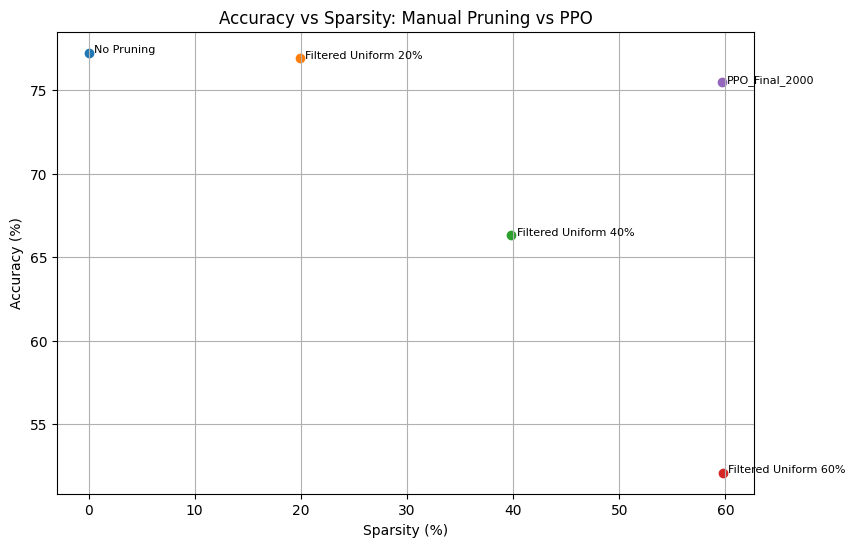

In [40]:
plt.figure(figsize=(9, 6))

for _, row in final_results_df.iterrows():
    plt.scatter(row["Sparsity (%)"], row["Accuracy (%)"])
    plt.text(
        row["Sparsity (%)"] + 0.5,
        row["Accuracy (%)"],
        row["Method"],
        fontsize=8
    )

plt.xlabel("Sparsity (%)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Sparsity: Manual Pruning vs PPO")
plt.grid(True)
plt.show()

19. Plot Reward Comparison

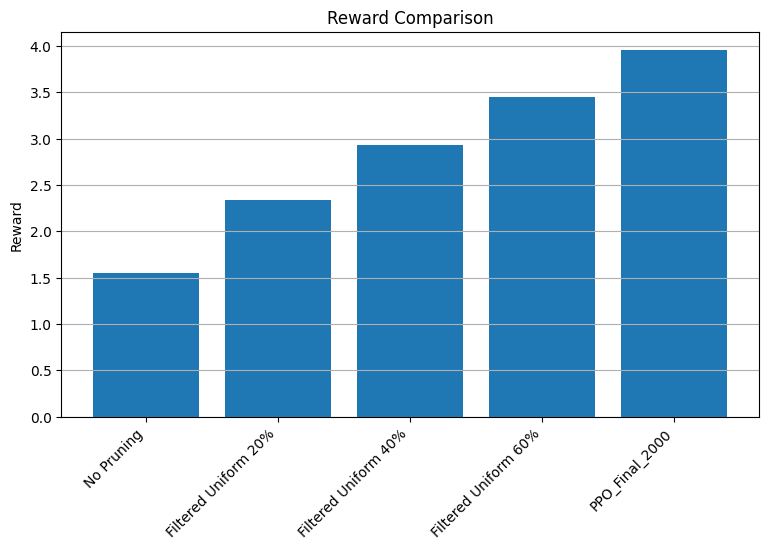

In [41]:
plt.figure(figsize=(9, 5))

plt.bar(final_results_df["Method"], final_results_df["Reward"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Reward")
plt.title("Reward Comparison")
plt.grid(axis="y")
plt.show()

20. Print Final Interpretation

In [42]:
best_row = final_results_df.sort_values("Reward", ascending=False).iloc[0]

print("Best method by reward:")
print(best_row)

print("\nFinal interpretation:")
print(
    f"The baseline model achieved {baseline_accuracy:.2f}% accuracy. "
    f"The PPO agent learned the pruning policy {ppo_final_result['Actions']}, "
    f"achieving {ppo_final_result['Accuracy (%)']:.2f}% accuracy and "
    f"{ppo_final_result['Sparsity (%)']:.2f}% sparsity."
)

Best method by reward:
Method          PPO_Final_2000
Actions           [1, 5, 5, 5]
Accuracy (%)             75.48
Sparsity (%)         59.682483
Reward                 3.95293
Name: 4, dtype: object

Final interpretation:
The baseline model achieved 77.25% accuracy. The PPO agent learned the pruning policy [1, 5, 5, 5], achieving 75.48% accuracy and 59.68% sparsity.


21. Optional: Run Multiple PPO Seeds

In [ ]:
ppo_multi_seed_results = []

for seed in [1, 2, 3]:
    print(f"\nTraining PPO with seed={seed}")

    train_env = CompressionEnvGym(
        base_model=baseline_model,
        prunable_layers=prunable_layers_filtered,
        baseline_accuracy=baseline_accuracy,
        eval_loader=small_val_loader,
        device=device,
        layer_sensitivities=layer_sensitivities
    )

    eval_env = CompressionEnvGym(
        base_model=baseline_model,
        prunable_layers=prunable_layers_filtered,
        baseline_accuracy=baseline_accuracy,
        eval_loader=test_loader,
        device=device,
        layer_sensitivities=layer_sensitivities
    )

    agent = PPO(
        policy="MlpPolicy",
        env=train_env,
        verbose=0,
        learning_rate=0.0003,
        n_steps=64,
        batch_size=32,
        n_epochs=10,
        gamma=0.99,
        ent_coef=0.01,
        seed=seed
    )

    agent.learn(total_timesteps=2000)

    result = evaluate_trained_agent(
        agent=agent,
        eval_env=eval_env,
        policy_name=f"PPO_Seed_{seed}"
    )

    result["Seed"] = seed
    ppo_multi_seed_results.append(result)

ppo_multi_seed_df = pd.DataFrame(ppo_multi_seed_results)
ppo_multi_seed_df


Training PPO with seed=1
